# Tutorial 1: Merge Multi-ROI Chromatin Trace Data

This tutorial walks through the standard workflow for merging chromatin tracing data from multiple regions of interest (ROIs):

1. **Collect** trace files from all ROIs into one folder
2. **Assess quality** by computing Pearson correlations between ROIs
3. **Remove** ROIs with poor correlation (outliers)
4. **Re-assess** the correlation matrix after removal
5. **Merge** the remaining trace files into a single table
6. **Statistics** on the merged dataset
7. **Next steps** — link to Tutorial 2 for quality control

## Step 0: Set-up your data and output path

In [11]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

Download datasets from docs/source/...

Set up your folder data and destination paths:

In [16]:
data_path = "/mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2"
dest_path = f"{data_path}/output"

Check ROIs detected:

In [4]:
print(f"Data path: {data_path}")
print(f"Output path: {dest_path}")
print(f"\nAvailable ROIs:")
for d in sorted(Path(data_path).iterdir()):
    if d.is_dir() and "FOV" in d.name:
        print(f"  {d.name}")

Data path: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2
Output path: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output

Available ROIs:
  FOV_26
  FOV_27
  FOV_28
  FOV_29
  FOV_30


## Step 1: Collect trace files from all ROIs

`collect_files` scans each subdirectory of `--root` for a file matching `--example-file`.
The `--variable-part "13"` indicates that the ROI number varies; fixed-length matching naturally excludes Matrix files (different filename length).

In [5]:
!collect_files --root {data_path} --example-file "FOV_26_4DNFI2HV38L6.csv" --variable-part "26" --copy-to {dest_path}/raw_traces --force

------- Running collect_files.py --------
Collect one file per subdirectory using pattern matching.

Matched (5):
  FOV_26 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/FOV_26/FOV_26_4DNFI2HV38L6.csv
  FOV_27 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/FOV_27/FOV_27_4DNFI2HV38L6.csv
  FOV_28 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/FOV_28/FOV_28_4DNFI2HV38L6.csv
  FOV_29 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/FOV_29/FOV_29_4DNFI2HV38L6.csv
  FOV_30 -> /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/FOV_30/FOV_30_4DNFI2HV38L6.csv
No match (1):
  plots
Ambiguous (1):
  output (4 matches):
    /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/raw_traces/FOV_26_4DNFI2HV38L6.csv
    /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/raw_traces/FOV_27_4DNFI2HV38L6.csv
    /mnt/grey/DATA/users/zidoum/traceraptops/data/B

## Step 2: Compute Pearson correlations between ROIs

`trace_pearsons` computes a pairwise distance map for each ROI (median 3D distance between every barcode pair), then calculates the Pearson correlation between these maps.

A high correlation between two ROIs means they share similar chromatin organization. An ROI with low correlation against all others is likely an outlier (imaging artifact, poor segmentation, etc.).

------- Running trace_pearsons.py --------
Compare chromatin trace tables by computing pairwise distances.

Analyzing 4 trace files...
Processing FOV_26_4DNFI2HV38L6.csv
Processing FOV_27_4DNFI2HV38L6.csv
Processing FOV_29_4DNFI2HV38L6.csv
Processing FOV_30_4DNFI2HV38L6.csv
$ Saved correlation matrix as /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/trace_correlation_matrix.npy


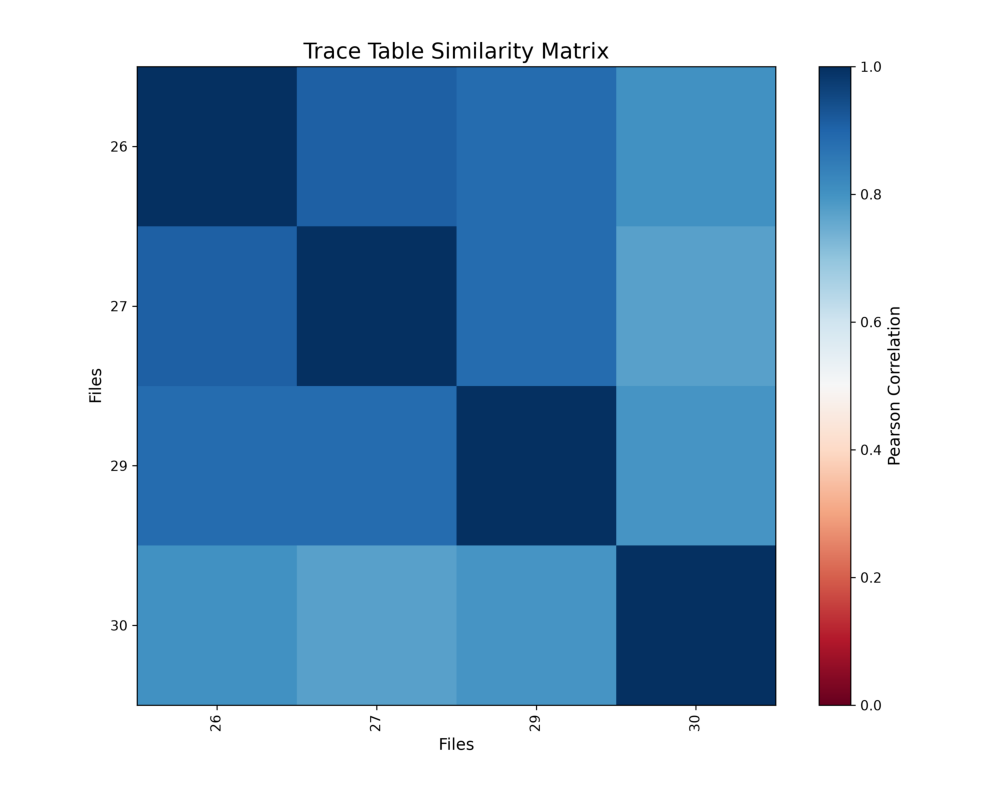

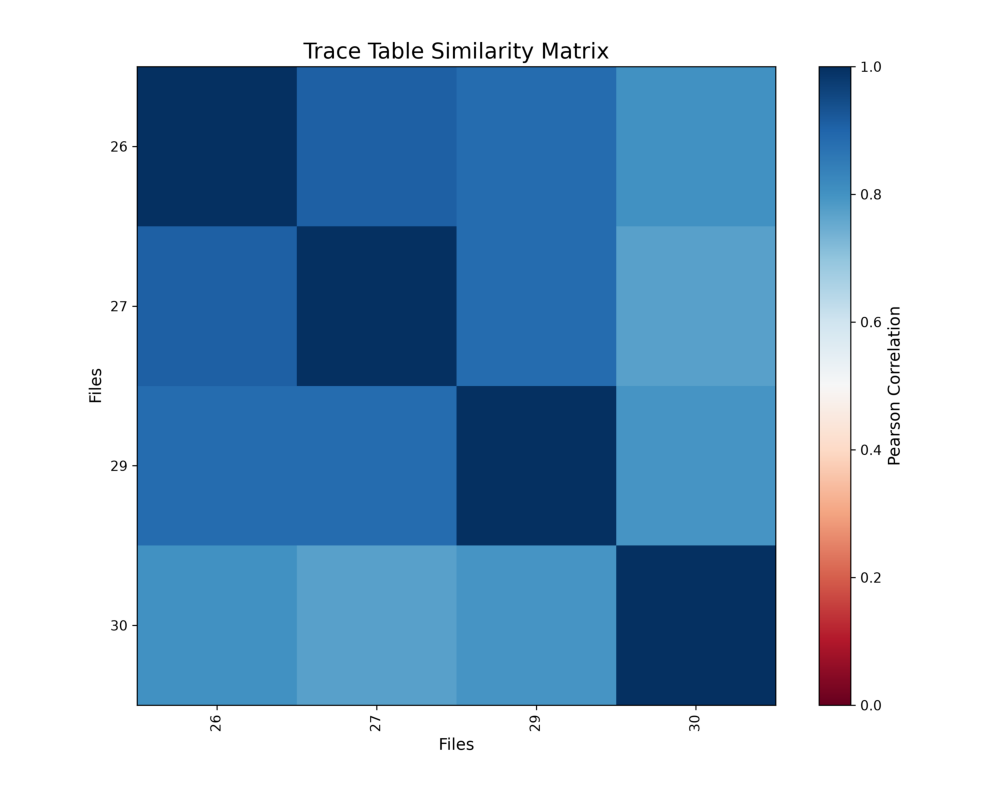

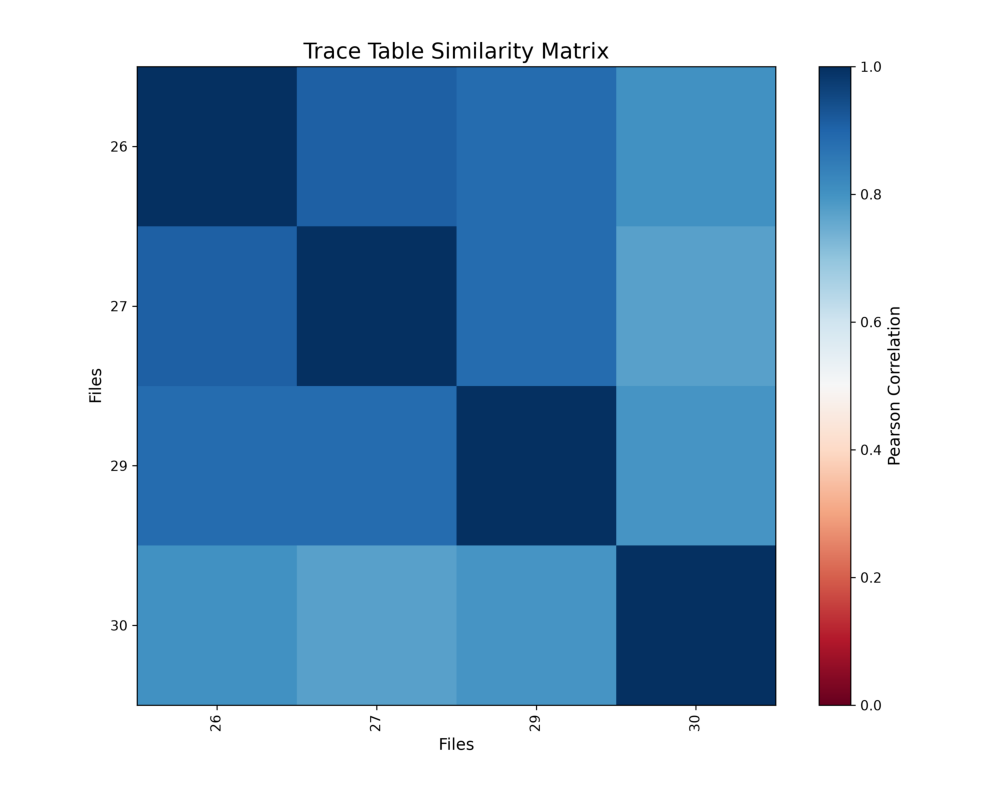

In [12]:
!ls {dest_path}/raw_traces/*.csv | trace_pearsons --pipe -O {dest_path}

# Display the correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 3: Remove poorly-correlated ROIs

For each ROI, we compute its **mean Pearson correlation** with all other ROIs. ROIs below the threshold are removed from the working folder before merging.

A threshold of **0.70** is conservative: it removes only clear outliers while preserving the vast majority of the data.

In [8]:
# Load the correlation matrix saved by trace_pearsons
corr = np.load(f"{dest_path}/trace_correlation_matrix.npy")
traces = sorted(Path(f"{dest_path}/raw_traces").glob("*.csv"))

# Mean correlation per ROI (exclude self-correlation on the diagonal)
np.fill_diagonal(corr, np.nan)
mean_corr = np.nanmean(corr, axis=1)

# Remove ROIs below threshold
threshold = 0.70
for trace, mc in zip(traces, mean_corr):
    if mc < threshold or np.isnan(mc):
        trace.unlink()
        print(f"Removed {trace.name}  (mean Pearson = {mc:.3f})")
    else:
        print(f"Kept    {trace.name}  (mean Pearson = {mc:.3f})")

Kept    FOV_26_4DNFI2HV38L6.csv  (mean Pearson = 0.864)
Kept    FOV_27_4DNFI2HV38L6.csv  (mean Pearson = 0.855)
Kept    FOV_29_4DNFI2HV38L6.csv  (mean Pearson = 0.854)
Kept    FOV_30_4DNFI2HV38L6.csv  (mean Pearson = 0.789)


## Step 4: Re-run Pearson to verify improvement

After removing the outlier ROIs, the correlation matrix should show higher overall values.

------- Running trace_pearsons.py --------
Compare chromatin trace tables by computing pairwise distances.

Analyzing 4 trace files...
Processing FOV_26_4DNFI2HV38L6.csv
Processing FOV_27_4DNFI2HV38L6.csv
Processing FOV_29_4DNFI2HV38L6.csv
Processing FOV_30_4DNFI2HV38L6.csv
$ Saved correlation matrix as /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/trace_correlation_matrix.png
$ Saved correlation matrix data in NPY format: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/trace_correlation_matrix.npy


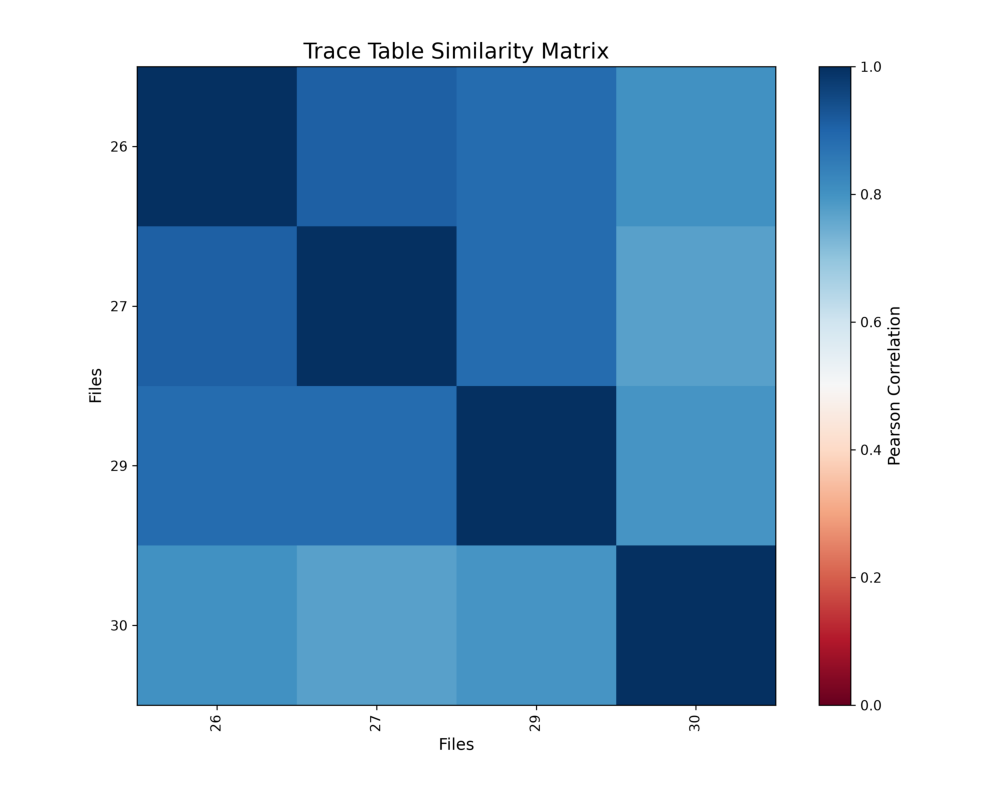

In [13]:
!ls {dest_path}/raw_traces/*.csv | trace_pearsons --pipe -O {dest_path}

# Display the updated correlation matrix
img = mpimg.imread(f"{dest_path}/trace_correlation_matrix.png")
fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img)
ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5: Merge trace files

In [14]:
!ls {dest_path}/raw_traces/*.csv | trace_merge -F {dest_path} -N merged_traces.ecsv

------- Running trace_merge.py --------
This script will merge trace tables provided as inputs.

Number of trace files to merge: 4
 $ Merged trace file will contain 94893 traces
Read and accumulated 4 trace files
$ Saving output table as /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv ...
Finished execution


## Step 6: Compute basic statistics

In [15]:
!trace_stats --input {dest_path}/merged_traces.ecsv

------- Running trace_stats.py --------
Compute basic statistics for chromatin trace files.

$ Importing table from pyHiM format
Successfully loaded trace table: /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv
Statistics for /mnt/grey/DATA/users/zidoum/traceraptops/data/Boettiger/Replicate2/output/merged_traces.ecsv:
- Number of unique ROIs: 4
- Number of unique chromatin traces: 1792
- Number of unique barcodes: 70


## Next steps

The merged trace file is ready for downstream analysis.

Continue with **Tutorial 2 — Quality Control** to:
- Generate detailed quality metrics with `trace_analyzer`
- Interpret barcode detection, neighbor distances, and barcode frequency plots
- Decide on filtering thresholds for Tutorial 3

## Summary

| Step | Script | Output |
|------|--------|--------|
| Collect | `collect_files` | `raw_traces/` (one .ecsv per ROI) |
| Correlations | `trace_pearsons` | `trace_correlation_matrix.png` + `.npy` |
| Filter ROIs | Python (numpy) | removed outlier files from `raw_traces/` |
| Merge | `trace_merge` | `merged_traces.ecsv` |
| Statistics | `trace_stats` | stdout |

**Output location:** `data/output/`